**8.1 DISTINCTION TASK (Machine Learning Mini Project)**

---

Student Name: Huynh Minh Tran

Student ID: s224874599

Unit: SIT307 - undergraduate

---

# Setup

I imported the libraries required for data handling, visualisation, preprocessing, regression modelling, cross-validation, evaluation, and model export. I also created dedicated folders for figures and the fitted model so that the notebook remains reproducible and the deployment files are kept organised.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold, RandomizedSearchCV, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style = 'whitegrid', palette = 'deep')

RANDOM_STATE = 42
FIGURE_DIR = Path('figures')
MODEL_DIR = Path('models')
FIGURE_DIR.mkdir(parents = True, exist_ok = True)
MODEL_DIR.mkdir(parents = True, exist_ok = True)

---

# 1. Problem Definition and Data Collection

The objective is to predict the sale price of houses in Liverpool, Ryde, and Mosman. I selected these suburbs because they represent three substantially different Sydney housing markets: Liverpool is comparatively affordable, Ryde occupies a middle market, and Mosman contains high-value prestige properties. This contrast should help the model learn the importance of location while providing a useful decision-support comparison for potential buyers.

I compiled 1,200 disclosed Domain sales, with 400 houses from each suburb. The dataset includes price, sale date and method, bedrooms, bathrooms, parking spaces, land size, and source details. Only houses were retained so that differences in property type did not dominate the comparison.

## 1.1 Loading and inspecting the dataset

I first load the submitted relative CSV path. A local fallback is included only to make development reproducible on my computer. The initial inspection checks dimensions, data types, descriptive statistics, missing values, and exact duplicate rows.

In [2]:
data_path = Path('sydney_house_sales.csv')

if not data_path.exists():
    fallback_path = Path(r'D:\SIT307\8.1D\sydney_house_sales.csv')
    if fallback_path.exists():
        data_path = fallback_path
    else:
        raise FileNotFoundError(
            'Place sydney_house_sales.csv in the same folder as this notebook.'
        )

df = pd.read_csv(data_path)

print('First five rows:')
display(df.head())
print(f'\nDataset shape: {df.shape}')
print('\nDataset information:')
df.info()
print('\nDescriptive statistics:')
display(df.describe(include = 'all').T)
print('\nMissing values:')
display(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

First five rows:


,listing_id,address,suburb,postcode,sale_price_aud,sale_date,sale_method,bedrooms,bathrooms,parking_spaces,land_size_sqm,property_type,source_website,source_url
0,2021020944,69 Orange Grove Road,Liverpool,2170,910000,17 Sep 2026,Sold by private treaty,3,2,1.0000,613.0000,House,Domain,https://www.domain.com.au/69-orange-grove-road...
1,2021129748,40 Maryvale Avenue,Liverpool,2170,1200000,15 Sep 2026,Sold by private treaty,3,1,1.0000,701.0000,House,Domain,https://www.domain.com.au/40-maryvale-avenue-l...
2,2020680196,3 Secant Street,Liverpool,2170,2000000,15 Sep 2026,Sold by private treaty,4,2,2.0000,676.0000,House,Domain,https://www.domain.com.au/3-secant-street-live...
3,2021040265,41 Tully Avenue,Liverpool,2170,1150000,11 Sep 2026,Sold by private treaty,6,2,2.0000,NaN,House,Domain,https://www.domain.com.au/41-tully-avenue-live...
4,2020980336,3 Edwin Place,Liverpool,2170,1235000,07 Sep 2026,Sold by private treaty,4,2,5.0000,613.0000,House,Domain,https://www.domain.com.au/3-edwin-place-liverp...



Dataset shape: (1200, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   listing_id      1200 non-null   int64  
 1   address         1200 non-null   object 
 2   suburb          1200 non-null   object 
 3   postcode        1200 non-null   int64  
 4   sale_price_aud  1200 non-null   int64  
 5   sale_date       1200 non-null   object 
 6   sale_method     1200 non-null   object 
 7   bedrooms        1200 non-null   int64  
 8   bathrooms       1200 non-null   int64  
 9   parking_spaces  1136 non-null   float64
 10  land_size_sqm   947 non-null    float64
 11  property_type   1200 non-null   object 
 12  source_website  1200 non-null   object 
 13  source_url      1200 non-null   object 
dtypes: float64(2), int64(5), object(7)
memory usage: 131.4+ KB

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,"1,200.0000",NaN,NaN,NaN,"2,019,371,246.4200","1,162,830.4357","2,015,878,699.0000","2,019,083,690.2500","2,019,584,011.0000","2,020,224,396.2500","2,021,129,748.0000"
address,1200,1163,22 Wolger Road,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb,1200,3,Liverpool,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postcode,"1,200.0000",NaN,NaN,NaN,"2,123.3333",34.4366,"2,088.0000","2,088.0000","2,112.0000","2,170.0000","2,170.0000"
sale_price_aud,"1,200.0000",NaN,NaN,NaN,"3,648,802.9250","3,724,276.4619","550,000.0000","1,210,000.0000","2,602,000.0000","4,305,000.0000","50,000,000.0000"
sale_date,1200,746,28 Sep 2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale_method,1200,3,Sold by private treaty,543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,"1,200.0000",NaN,NaN,NaN,4.0825,1.1620,1.0000,3.0000,4.0000,5.0000,11.0000
bathrooms,"1,200.0000",NaN,NaN,NaN,2.2808,1.1089,1.0000,1.0000,2.0000,3.0000,9.0000
parking_spaces,"1,136.0000",NaN,NaN,NaN,2.1910,1.1931,1.0000,1.0000,2.0000,3.0000,12.0000



Missing values:


listing_id          0
address             0
suburb              0
postcode            0
sale_price_aud      0
sale_date           0
sale_method         0
bedrooms            0
bathrooms           0
parking_spaces     64
land_size_sqm     253
property_type       0
source_website      0
source_url          0
dtype: int64


Duplicate rows: 0


The dataset contains **1,200 observations and 14 columns**, with 400 properties from each suburb. Sale price, bedrooms, and bathrooms are complete. Parking has 64 missing values and land size has 253. There are no exact duplicate rows. The source fields are retained for traceability but will not be used as predictors.

## 1.2 Data preparation and quality checks

I preserve the original DataFrame and correct identifier and date types in a working copy. Listing IDs and postcodes are labels rather than quantities. The mixed date parser supports both the submitted CSV format and the original collection format.

In [3]:
df_clean = df.copy()

df_clean['listing_id'] = df_clean['listing_id'].astype('string')
df_clean['postcode'] = df_clean['postcode'].astype('string')
df_clean['sale_date'] = pd.to_datetime(
    df_clean['sale_date'],
    format = 'mixed',
    dayfirst = True
)

missing_by_suburb = (
    df_clean
    .groupby('suburb')[['parking_spaces', 'land_size_sqm']]
    .agg(lambda column: column.isnull().mean() * 100)
    .reindex(['Liverpool', 'Ryde', 'Mosman'])
    .round(1)
)

print('Updated data types:')
print(df_clean.dtypes)

print('\nRecords per suburb:')
print(df_clean['suburb'].value_counts())

print('\nSale methods:')
print(df_clean['sale_method'].value_counts())

print('\nData quality checks:')
print(f'Duplicate listing IDs: {df_clean["listing_id"].duplicated().sum()}')
print(
    'Duplicate property-sale transactions: '
    f'{df_clean.duplicated(subset=["suburb", "address", "sale_date"]).sum()}'
)
print(f'Duplicate source URLs: {df_clean["source_url"].duplicated().sum()}')
print(f'Invalid sale prices: {(df_clean["sale_price_aud"] <= 0).sum()}')
print(f'Invalid bedroom values: {(df_clean["bedrooms"] <= 0).sum()}')
print(f'Invalid bathroom values: {(df_clean["bathrooms"] <= 0).sum()}')

print('\nMissing-value percentages by suburb:')
print(
    missing_by_suburb.to_string(
        formatters = {
            'parking_spaces': lambda value: f'{value:.1f}%',
            'land_size_sqm': lambda value: f'{value:.1f}%'
        }
    )
)

Updated data types:
listing_id        string[python]
address                   object
suburb                    object
postcode          string[python]
sale_price_aud             int64
sale_date         datetime64[ns]
sale_method               object
bedrooms                   int64
bathrooms                  int64
parking_spaces           float64
land_size_sqm            float64
property_type             object
source_website            object
source_url                object
dtype: object

Records per suburb:
suburb
Liverpool    400
Ryde         400
Mosman       400
Name: count, dtype: int64

Sale methods:
sale_method
Sold by private treaty    543
Sold at auction           412
Sold prior to auction     245
Name: count, dtype: int64

Data quality checks:
Duplicate listing IDs: 0
Duplicate property-sale transactions: 0
Duplicate source URLs: 0
Invalid sale prices: 0
Invalid bedroom values: 0
Invalid bathroom values: 0

Missing-value percentages by suburb:
          parking_spaces land_

The three suburbs are balanced at 400 observations each. All sale prices, bedroom counts, and bathroom counts are positive, while no duplicate listing IDs, property-sale transactions, or source URLs were found. The dataset covers sales from February 2020 to September 2026, although the printed range only describes the dataset as a whole and does not confirm equal date coverage across the three suburbs.

Missingness differs by location. Parking-space missingness is 5.2% in Liverpool, 1.2% in Ryde, and 9.5% in Mosman, while land-size missingness is 10.8%, 24.2%, and 28.2% respectively. These observations are retained to avoid discarding a substantial amount of data, with median imputation fitted inside each training fold to prevent leakage. As the manually collected dataset is limited to disclosed Domain sales, it may under-represent private or undisclosed transactions; predictions should therefore be treated as decision-support estimates rather than formal valuations.

---

# 2. Data Analysis and Feature Engineering

## 2.1 Price distributions and suburb differences

I summarise and visualise sale prices by suburb. The histogram shows the shape of each distribution, while the boxplot makes differences in medians, spread, and unusual high-value observations easier to compare.

Sale price summary by suburb:


,count,mean,median,std,min,max
suburb,,,,,,
Liverpool,400,"$1,079,479","$1,001,000","$320,487","$550,000","$3,000,000"
Ryde,400,"$2,696,920","$2,607,000","$606,954","$1,300,000","$5,800,000"
Mosman,400,"$7,170,010","$6,000,000","$4,610,079","$2,210,000","$50,000,000"


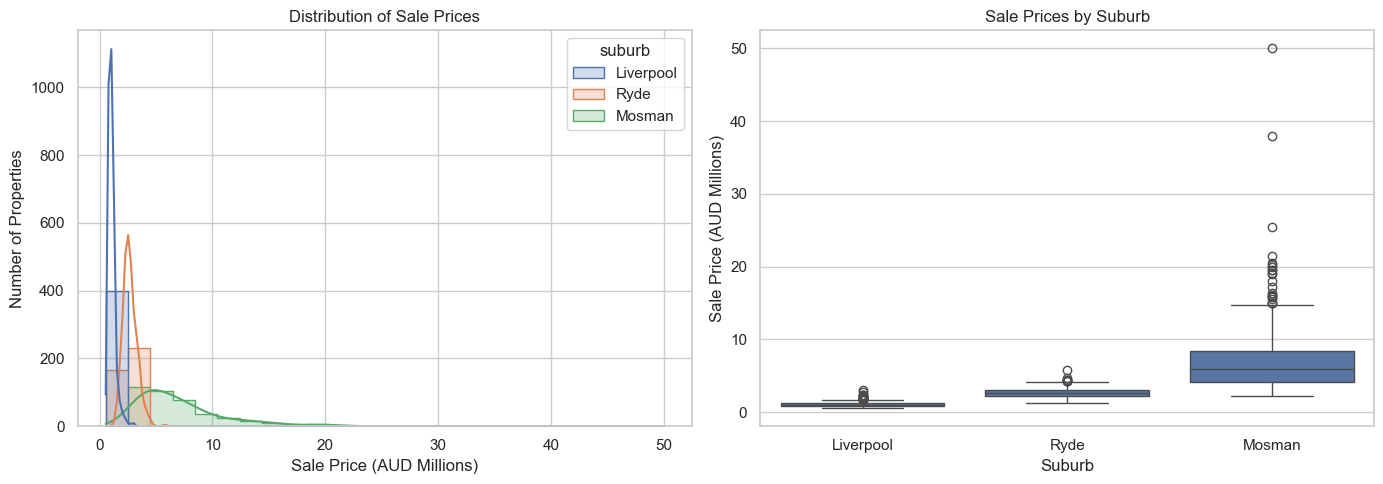

In [4]:
suburb_order = ['Liverpool', 'Ryde', 'Mosman']

price_summary = (
    df_clean.groupby('suburb')['sale_price_aud']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(suburb_order)
)

print('Sale price summary by suburb:')
display(
    price_summary.style.format({
        'mean': '${:,.0f}',
        'median': '${:,.0f}',
        'std': '${:,.0f}',
        'min': '${:,.0f}',
        'max': '${:,.0f}'
    })
)

plot_df = df_clean.assign(
    sale_price_millions = df_clean['sale_price_aud'] / 1_000_000
)

figure, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.histplot(
    data = plot_df,
    x = 'sale_price_millions',
    hue = 'suburb',
    hue_order = suburb_order,
    bins = 25,
    kde = True,
    element = 'step',
    ax = axes[0]
)
axes[0].set_title('Distribution of Sale Prices')
axes[0].set_xlabel('Sale Price (AUD Millions)')
axes[0].set_ylabel('Number of Properties')

sns.boxplot(
    data = plot_df,
    x = 'suburb',
    y = 'sale_price_millions',
    order = suburb_order,
    ax = axes[1]
)
axes[1].set_title('Sale Prices by Suburb')
axes[1].set_xlabel('Suburb')
axes[1].set_ylabel('Sale Price (AUD Millions)')

plt.tight_layout()
figure.savefig(
    FIGURE_DIR / 'sale_price_distribution_by_suburb.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

The suburb distributions are clearly separated. Median prices rise from **\\$1.00 million in Liverpool** to **\\$2.61 million in Ryde** and **\\$6.00 million in Mosman**. Mosman also has the greatest variation, with a standard deviation of approximately \\$4.61 million and a maximum of \\$50.00 million. Its strong right tail represents a genuine prestige segment, so I retain these observations rather than removing them solely through an automatic outlier rule. This choice makes the evaluation more realistic, but it also increases RMSE when rare luxury properties are underpredicted.

## 2.2 Time trends and property characteristics

I next examine monthly median prices and the relationships between price, land size, and bedrooms. Monthly medians are used because they are less sensitive than means to the small number of exceptional Mosman sales.

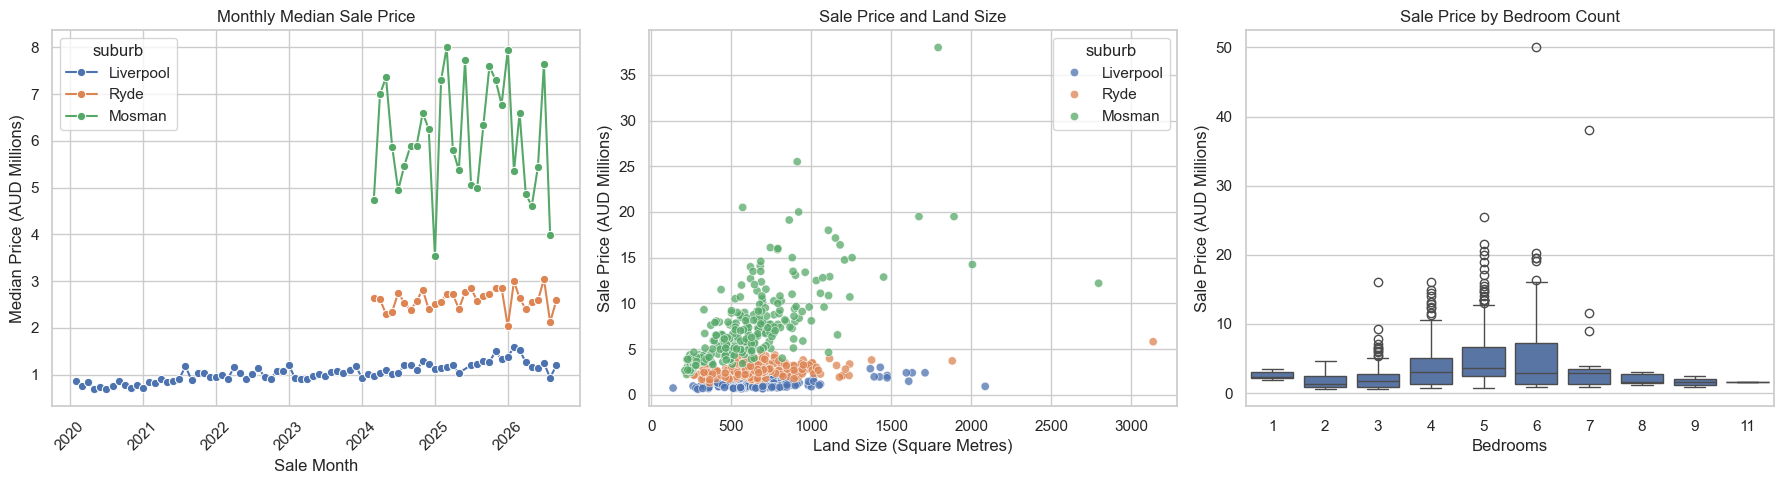

In [5]:
monthly_prices = (
    df_clean.set_index('sale_date')
    .groupby('suburb')['sale_price_aud']
    .resample('MS')
    .median()
    .reset_index()
)
monthly_prices['sale_price_millions'] = (
    monthly_prices['sale_price_aud'] / 1_000_000
)

figure, axes = plt.subplots(1, 3, figsize = (18, 5))
sns.lineplot(
    data = monthly_prices,
    x = 'sale_date',
    y = 'sale_price_millions',
    hue = 'suburb',
    hue_order = suburb_order,
    marker = 'o',
    ax = axes[0]
)
axes[0].set_title('Monthly Median Sale Price')
axes[0].set_xlabel('Sale Month')
axes[0].set_ylabel('Median Price (AUD Millions)')
axes[0].tick_params(axis = 'x', rotation = 45)

sns.scatterplot(
    data = plot_df,
    x = 'land_size_sqm',
    y = 'sale_price_millions',
    hue = 'suburb',
    hue_order = suburb_order,
    alpha = 0.75,
    ax = axes[1]
)
axes[1].set_title('Sale Price and Land Size')
axes[1].set_xlabel('Land Size (Square Metres)')
axes[1].set_ylabel('Sale Price (AUD Millions)')

sns.boxplot(
    data = plot_df,
    x = 'bedrooms',
    y = 'sale_price_millions',
    ax = axes[2]
)
axes[2].set_title('Sale Price by Bedroom Count')
axes[2].set_xlabel('Bedrooms')
axes[2].set_ylabel('Sale Price (AUD Millions)')

plt.tight_layout()
figure.savefig(
    FIGURE_DIR / 'time_and_property_relationships.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

The monthly medians remain separated by suburb, although individual months fluctuate because each contains relatively few sales. Land size and bedroom count show positive relationships with price, but properties with similar physical measurements still have very different values across suburbs. This supports location as the dominant predictor and shows why size variables alone cannot explain Mosman's prestige premium. It also confirms that the most expensive observations are concentrated in Mosman rather than being isolated data-entry errors.

## 2.3 Expected predictors and engineered features

Before engineering features, I expect **suburb, land size, and bedrooms** to have the strongest influence. Suburb represents location and market segment, land is a scarce component of house value, and bedrooms approximate usable capacity. I create sale year and month to represent market timing, total rooms to combine accommodation capacity, and land per bedroom to distinguish spacious properties from houses placing many bedrooms on a smaller block.

In [6]:
df_model = df_clean.copy()

df_model['sale_year'] = df_model['sale_date'].dt.year
df_model['sale_month'] = df_model['sale_date'].dt.month
df_model['total_rooms'] = (
    df_model['bedrooms'] + df_model['bathrooms']
)
df_model['land_per_bedroom'] = (
    df_model['land_size_sqm'] / df_model['bedrooms']
)

numeric_features = [
    'bedrooms',
    'bathrooms',
    'parking_spaces',
    'land_size_sqm',
    'sale_year',
    'sale_month',
    'total_rooms',
    'land_per_bedroom'
]
categorical_features = ['suburb', 'sale_method']
feature_columns = numeric_features + categorical_features
target_column = 'sale_price_aud'

X = df_model[feature_columns]
y = df_model[target_column]

print('Model input shape:', X.shape)
print('Target shape:', y.shape)
display(X.head())

Model input shape: (1200, 10)
Target shape: (1200,)


,bedrooms,bathrooms,parking_spaces,land_size_sqm,sale_year,sale_month,total_rooms,land_per_bedroom,suburb,sale_method
0,3,2,1.0000,613.0000,2026,9,5,204.3333,Liverpool,Sold by private treaty
1,3,1,1.0000,701.0000,2026,9,4,233.6667,Liverpool,Sold by private treaty
2,4,2,2.0000,676.0000,2026,9,6,169.0000,Liverpool,Sold by private treaty
3,6,2,2.0000,NaN,2026,9,8,NaN,Liverpool,Sold by private treaty
4,4,2,5.0000,613.0000,2026,9,6,153.2500,Liverpool,Sold by private treaty


The model input contains eight numerical and two categorical predictors. Address, listing ID, postcode, source URL, and source website are excluded because they are identifiers, redundant location labels, or collection metadata. Property type is excluded because every observation is a house and therefore contains no predictive variation.

---

# 3. Model Development and Evaluation

## 3.1 Model selection and preprocessing

I compare three regression approaches. **Ridge Regression** provides an interpretable linear baseline and controls unstable coefficients through regularisation. **Random Forest** represents bagging and can learn non-linear relationships and interactions. **Gradient Boosting** builds trees sequentially to correct earlier errors and provides a useful comparison for whether additional optimisation improves practical performance. I select the deployment model from cross-validation results rather than assuming that the most heavily tuned model must be best.

Numerical missing values are median-imputed inside each fold. Categorical variables are one-hot encoded, and only Ridge inputs are standardised. I apply a `log1p` target transformation to all models because the price distribution is strongly right-skewed. Predictions are automatically converted back to Australian dollars before evaluation.

In [7]:
numeric_scaled = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
numeric_unscaled = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown = 'ignore',
        sparse_output = False
    ))
])

linear_preprocessor = ColumnTransformer([
    ('numeric', numeric_scaled, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])
tree_preprocessor = ColumnTransformer([
    ('numeric', numeric_unscaled, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

base_models = {
    'Ridge Regression': Pipeline([
        ('preprocessor', linear_preprocessor),
        ('model', Ridge(alpha = 10.0))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', RandomForestRegressor(
            n_estimators = 500,
            max_depth = 8,
            min_samples_leaf = 2,
            max_features = 0.8,
            random_state = RANDOM_STATE,
            n_jobs = -1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators = 200,
            learning_rate = 0.03,
            max_depth = 2,
            min_samples_leaf = 3,
            random_state = RANDOM_STATE
        ))
    ])
}

models = {
    name: TransformedTargetRegressor(
        regressor = model,
        func = np.log1p,
        inverse_func = np.expm1
    )
    for name, model in base_models.items()
}

cv_strategy = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = RANDOM_STATE
)
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

## 3.2 Five-fold cross-validation

I evaluate every model with the same shuffled five-fold split. MAE reports the typical dollar error, RMSE gives greater weight to large failures, and R² reports the proportion of price variation explained. Training scores are included to diagnose underfitting and overfitting rather than selecting a model from one favourable split.


,Training MAE,CV MAE,CV MAE SD,Training RMSE,CV RMSE,CV RMSE SD,Training R2,CV R2,CV R2 SD
Model,,,,,,,,,
Random Forest,"$546,182","$787,936","$85,344","$1,462,392","$1,925,710","$544,551",0.8446,0.7228,0.0895
Gradient Boosting,"$751,680","$832,427","$94,175","$1,856,438","$2,066,698","$616,494",0.7497,0.6825,0.1047
Ridge Regression,"$867,449","$888,821","$103,385","$2,000,376","$1,996,836","$504,728",0.7102,0.7047,0.0672


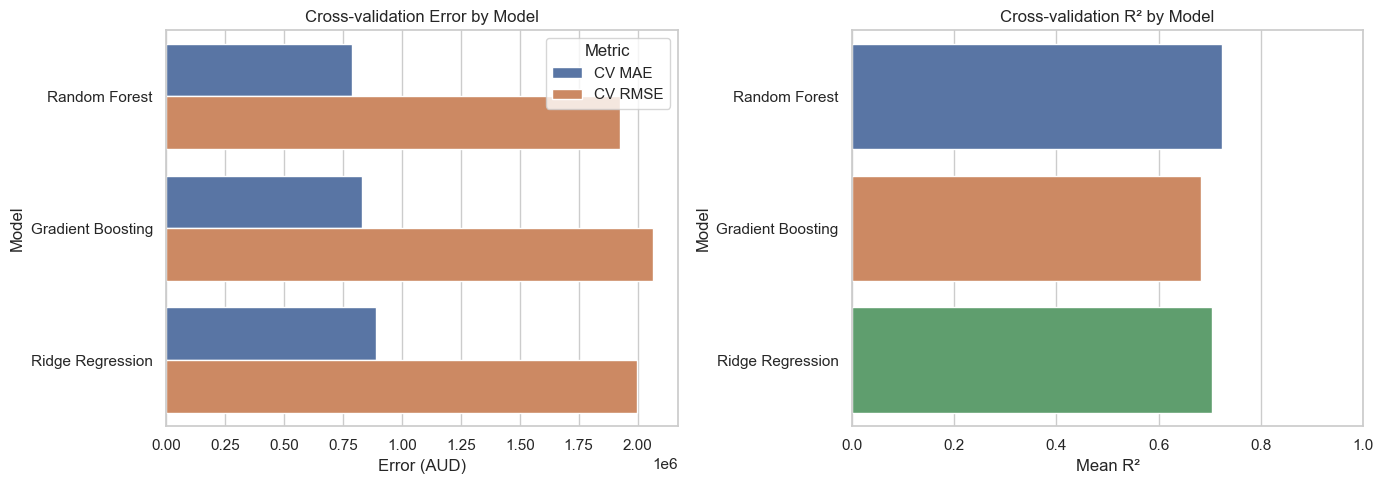

In [8]:
model_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv = cv_strategy,
        scoring = scoring,
        return_train_score = True,
        n_jobs = 1
    )

    model_results.append({
        'Model': model_name,
        'Training MAE': -scores['train_MAE'].mean(),
        'CV MAE': -scores['test_MAE'].mean(),
        'CV MAE SD': scores['test_MAE'].std(),
        'Training RMSE': -scores['train_RMSE'].mean(),
        'CV RMSE': -scores['test_RMSE'].mean(),
        'CV RMSE SD': scores['test_RMSE'].std(),
        'Training R2': scores['train_R2'].mean(),
        'CV R2': scores['test_R2'].mean(),
        'CV R2 SD': scores['test_R2'].std()
    })

model_comparison = (
    pd.DataFrame(model_results)
    .set_index('Model')
    .sort_values('CV MAE')
)

display(
    model_comparison.style.format({
        'Training MAE': '${:,.0f}',
        'CV MAE': '${:,.0f}',
        'CV MAE SD': '${:,.0f}',
        'Training RMSE': '${:,.0f}',
        'CV RMSE': '${:,.0f}',
        'CV RMSE SD': '${:,.0f}',
        'Training R2': '{:.4f}',
        'CV R2': '{:.4f}',
        'CV R2 SD': '{:.4f}'
    }).highlight_min(
        subset = ['CV MAE', 'CV RMSE'],
        color = 'lightgreen'
    ).highlight_max(
        subset = ['CV R2'],
        color = 'lightgreen'
    )
)

comparison_plot = model_comparison.reset_index().melt(
    id_vars = 'Model',
    value_vars = ['CV MAE', 'CV RMSE'],
    var_name = 'Metric',
    value_name = 'Error'
)

figure, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.barplot(
    data = comparison_plot,
    x = 'Error',
    y = 'Model',
    hue = 'Metric',
    ax = axes[0]
)
axes[0].set_title('Cross-validation Error by Model')
axes[0].set_xlabel('Error (AUD)')
axes[0].set_ylabel('Model')

sns.barplot(
    data = model_comparison.reset_index(),
    x = 'CV R2',
    y = 'Model',
    hue = 'Model',
    legend = False,
    ax = axes[1]
)
axes[1].set_title('Cross-validation R² by Model')
axes[1].set_xlabel('Mean R²')
axes[1].set_ylabel('Model')
axes[1].set_xlim(0, 1)

plt.tight_layout()
figure.savefig(
    FIGURE_DIR / 'model_comparison.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

Random Forest performs best in the initial comparison, achieving the lowest cross-validation MAE of **\\$787,936**, alongside an RMSE of **\\$1,925,710** and an R² of **0.7228**. Its training MAE of $546,182 and training R² of 0.8446 indicate some overfitting, but it still provides the strongest validation performance according to the primary selection metric.

Gradient Boosting records a higher MAE of \\$832,427 and a lower R² of 0.6825. Ridge Regression is the weakest model by MAE at \\$888,821, although its R² of 0.7047 exceeds the original Gradient Boosting result. This suggests that the relationship between the predictors and sale price is not fully linear, while the Random Forest is better able to capture non-linear relationships and interactions. Random Forest is therefore selected as the leading baseline model before testing whether fine-tuning can produce a meaningful improvement.

## 3.3 Gradient Boosting fine-tuning comparison

Random Forest performs best in the initial comparison based on MAE. I nevertheless retain the Gradient Boosting fine-tuning experiment to test whether a computationally intensive search can produce a meaningful practical improvement. An inner four-fold randomised search is evaluated on five untouched outer folds. This nested design prevents the same validation results from being used both to select settings and to claim improved performance. The search varies learning rate, estimator count, depth, minimum split and leaf sizes, subsampling, and feature sampling.

In [9]:
inner_cv = KFold(
    n_splits = 4,
    shuffle = True,
    random_state = RANDOM_STATE
)

gradient_boosting_search = RandomizedSearchCV(
    estimator = models['Gradient Boosting'],
    param_distributions = {
        'regressor__model__n_estimators': [100, 150, 200, 300, 400, 600],
        'regressor__model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
        'regressor__model__max_depth': [1, 2, 3],
        'regressor__model__min_samples_leaf': [1, 2, 3, 5, 8, 10],
        'regressor__model__min_samples_split': [2, 4, 8, 12],
        'regressor__model__subsample': [0.6, 0.8, 1.0],
        'regressor__model__max_features': [None, 'sqrt', 0.8]
    },
    n_iter = 30,
    scoring = 'neg_mean_absolute_error',
    cv = inner_cv,
    random_state = RANDOM_STATE,
    n_jobs = 1,
    refit = True
)

tuned_scores = cross_validate(
    gradient_boosting_search,
    X,
    y,
    cv = cv_strategy,
    scoring = scoring,
    return_train_score = True,
    n_jobs = 1
)

gradient_boosting_search.fit(X, y)
tuned_gradient_boosting = gradient_boosting_search.best_estimator_

tuning_comparison = pd.DataFrame({
    'Original Gradient Boosting': {
        'CV MAE': model_comparison.loc['Gradient Boosting', 'CV MAE'],
        'CV RMSE': model_comparison.loc['Gradient Boosting', 'CV RMSE'],
        'CV R2': model_comparison.loc['Gradient Boosting', 'CV R2']
    },
    'Tuned Gradient Boosting': {
        'CV MAE': -tuned_scores['test_MAE'].mean(),
        'CV RMSE': -tuned_scores['test_RMSE'].mean(),
        'CV R2': tuned_scores['test_R2'].mean()
    }
}).T

display(
    tuning_comparison.style.format({
        'CV MAE': '${:,.0f}',
        'CV RMSE': '${:,.0f}',
        'CV R2': '{:.4f}'
    })
)
print('Best parameters:')
print('\n', gradient_boosting_search.best_params_)
print(f'Nested CV MAE standard deviation: ${tuned_scores["test_MAE"].std():,.0f}')

,CV MAE,CV RMSE,CV R2
Original Gradient Boosting,"$832,427","$2,066,698",0.6825
Tuned Gradient Boosting,"$799,634","$1,927,779",0.7234


Best parameters:

 {'regressor__model__subsample': 0.6, 'regressor__model__n_estimators': 200, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 10, 'regressor__model__max_features': 'sqrt', 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.08}
Nested CV MAE standard deviation: $104,674


Fine-tuning improves Gradient Boosting MAE from **\\$832,427 to \\$799,634**, reduces RMSE from **\\$2,066,698 to \\$1,927,779**, and increases R² from **0.6825 to 0.7234**. The selected configuration uses 200 trees, a learning rate of 0.08, 60% subsampling, a maximum depth of 3, a minimum leaf size of 10, a minimum split size of 2, and square-root feature sampling. The tuned model's outer-fold MAE has a standard deviation of approximately $104,674.

Despite this improvement over the original Gradient Boosting model, the tuned result does not provide a practical advantage over the untuned Random Forest. Random Forest has a lower MAE of **\\$787,936**, while their RMSE values differ by only about $2,000 and tuned Gradient Boosting's R² advantage is only **0.0006**. Achieving that negligible R² difference requires hundreds of model fits during nested randomised search. I therefore retain Random Forest for deployment because it produces the best typical dollar error without requiring an expensive tuning process. The tuning experiment remains as evidence that additional search was tested rather than assumed to be beneficial.


## 3.4 Evaluating the engineered features

To test whether feature engineering added value, I compare Gradient Boosting with the original property and category variables against the engineered feature set under the same cross-validation procedure.

In [10]:
baseline_numeric = [
    'bedrooms',
    'bathrooms',
    'parking_spaces',
    'land_size_sqm'
]
baseline_categorical = ['suburb', 'sale_method']
baseline_columns = baseline_numeric + baseline_categorical

baseline_preprocessor = ColumnTransformer([
    ('numeric', numeric_unscaled, baseline_numeric),
    ('categorical', categorical_pipeline, baseline_categorical)
])
baseline_gradient_boosting = TransformedTargetRegressor(
    regressor = Pipeline([
        ('preprocessor', baseline_preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators = 200,
            learning_rate = 0.03,
            max_depth = 2,
            min_samples_leaf = 3,
            random_state = RANDOM_STATE
        ))
    ]),
    func = np.log1p,
    inverse_func = np.expm1
)

baseline_scores = cross_validate(
    baseline_gradient_boosting,
    df_model[baseline_columns],
    y,
    cv = cv_strategy,
    scoring = scoring,
    n_jobs = 1
)

feature_comparison = pd.DataFrame({
    'Original Features': {
        'CV MAE': -baseline_scores['test_MAE'].mean(),
        'CV RMSE': -baseline_scores['test_RMSE'].mean(),
        'CV R2': baseline_scores['test_R2'].mean()
    },
    'Engineered Features': {
        'CV MAE': model_comparison.loc['Gradient Boosting', 'CV MAE'],
        'CV RMSE': model_comparison.loc['Gradient Boosting', 'CV RMSE'],
        'CV R2': model_comparison.loc['Gradient Boosting', 'CV R2']
    }
}).T

display(
    feature_comparison.style.format({
        'CV MAE': '${:,.0f}',
        'CV RMSE': '${:,.0f}',
        'CV R2': '{:.4f}'
    })
)

,CV MAE,CV RMSE,CV R2
Original Features,"$847,304","$2,069,732",0.6815
Engineered Features,"$832,427","$2,066,698",0.6825


The engineered features reduce Gradient Boosting MAE from approximately **\\$847,304 to \\$832,427** and RMSE from **\\$2,069,732 to \\$2,066,698**. R² increases only from **0.6815 to 0.6825**. The improvement is modest, showing that suburb and the original physical variables already contain most of the available signal. I retain the engineered timing and size-ratio features because they are logically relevant and do not introduce leakage, while recognising that richer source data would contribute more than further feature combinations.

---

# 4. Investigating Prediction Failures

I generate out-of-fold predictions from the selected Random Forest model. Each property is predicted by a model that was not trained on that transaction, making the resulting errors more defensible than errors calculated after fitting on all observations.

Selected model: Random Forest
Out-of-fold MAE: $787,936
Out-of-fold RMSE: $2,001,224
Out-of-fold R2: 0.7110


,listing_id,address,suburb,sale_price_aud,bedrooms,bathrooms,parking_spaces,land_size_sqm,sale_date,predicted_price_aud,residual_aud,absolute_error_aud,percentage_error
912,2020635348,3 Kirkoswald Avenue,Mosman,"$50,000,000",6,9,3.000000,nan,2025-10-13 00:00:00,"$13,022,296","$36,977,704","$36,977,704",74.0%
880,2020350821,28 Ruby Street,Mosman,"$38,000,000",7,6,6.000000,"1,792",2025-12-11 00:00:00,"$18,090,690","$19,909,310","$19,909,310",52.4%
875,2020626570,21 Balmoral Avenue,Mosman,"$20,500,000",5,3,2.000000,570,2025-12-19 00:00:00,"$6,365,504","$14,134,496","$14,134,496",68.9%
1095,2019394158,15 Burton Street,Mosman,"$20,200,000",6,3,1.000000,nan,2024-09-06 00:00:00,"$7,016,274","$13,183,726","$13,183,726",65.3%
960,2019843950,37 Carrington Avenue,Mosman,"$21,500,000",5,4,2.000000,nan,2025-06-12 00:00:00,"$9,246,527","$12,253,473","$12,253,473",57.0%


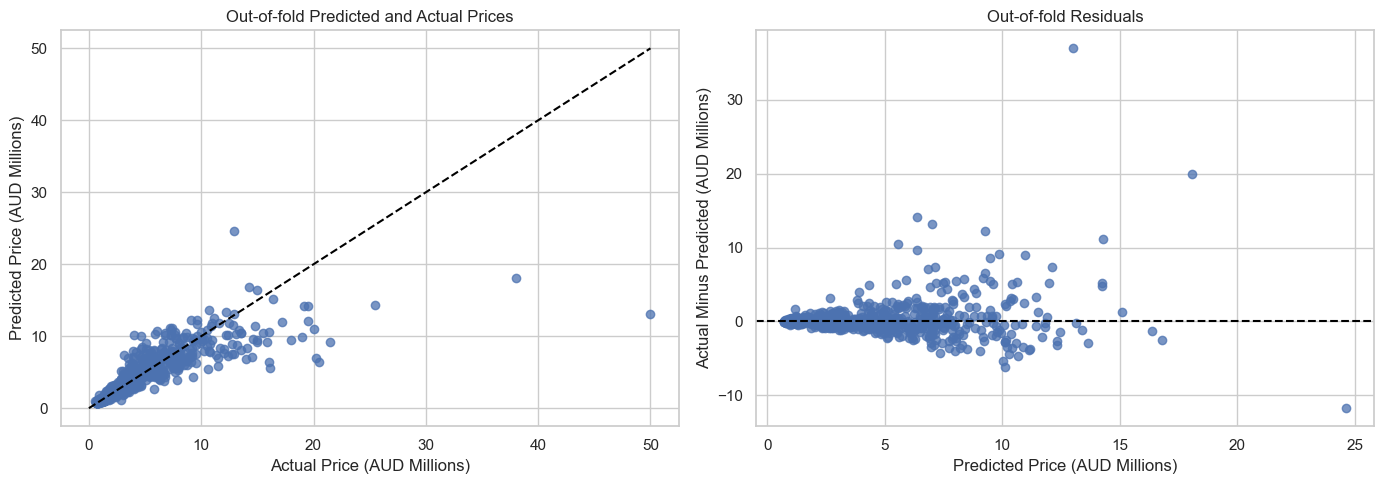

In [11]:
best_model_name = model_comparison.index[0]
best_model = models[best_model_name]

oof_predictions = cross_val_predict(
    best_model,
    X,
    y,
    cv = cv_strategy,
    n_jobs = 1
)

oof_mae = mean_absolute_error(y, oof_predictions)
oof_rmse = root_mean_squared_error(y, oof_predictions)
oof_r2 = r2_score(y, oof_predictions)

print('Selected model:', best_model_name)
print(f'Out-of-fold MAE: ${oof_mae:,.0f}')
print(f'Out-of-fold RMSE: ${oof_rmse:,.0f}')
print(f'Out-of-fold R2: {oof_r2:.4f}')

error_analysis = df_model[[
    'listing_id',
    'address',
    'suburb',
    'sale_price_aud',
    'bedrooms',
    'bathrooms',
    'parking_spaces',
    'land_size_sqm',
    'sale_date'
]].copy()
error_analysis['predicted_price_aud'] = oof_predictions
error_analysis['residual_aud'] = (
    error_analysis['sale_price_aud']
    - error_analysis['predicted_price_aud']
)
error_analysis['absolute_error_aud'] = error_analysis['residual_aud'].abs()
error_analysis['percentage_error'] = (
    error_analysis['absolute_error_aud']
    / error_analysis['sale_price_aud']
    * 100
)

largest_errors = error_analysis.nlargest(5, 'absolute_error_aud')
display(
    largest_errors.style.format({
        'sale_price_aud': '${:,.0f}',
        'predicted_price_aud': '${:,.0f}',
        'residual_aud': '${:,.0f}',
        'absolute_error_aud': '${:,.0f}',
        'percentage_error': '{:.1f}%',
        'land_size_sqm': '{:,.0f}'
    })
)

figure, axes = plt.subplots(1, 2, figsize = (14, 5))
axes[0].scatter(y / 1_000_000, oof_predictions / 1_000_000, alpha = 0.75)
price_limit = max(y.max(), oof_predictions.max()) / 1_000_000
axes[0].plot([0, price_limit], [0, price_limit], color = 'black', linestyle = '--')
axes[0].set_title('Out-of-fold Predicted and Actual Prices')
axes[0].set_xlabel('Actual Price (AUD Millions)')
axes[0].set_ylabel('Predicted Price (AUD Millions)')

axes[1].scatter(
    oof_predictions / 1_000_000,
    error_analysis['residual_aud'] / 1_000_000,
    alpha = 0.75
)
axes[1].axhline(0, color = 'black', linestyle = '--')
axes[1].set_title('Out-of-fold Residuals')
axes[1].set_xlabel('Predicted Price (AUD Millions)')
axes[1].set_ylabel('Actual Minus Predicted (AUD Millions)')

plt.tight_layout()
figure.savefig(
    FIGURE_DIR / 'prediction_errors.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

All five largest errors are underpredictions of prestige Mosman houses. The largest is **3 Kirkoswald Avenue**, sold for \\$50.00 million but predicted at approximately \\$13.02 million. **28 Ruby Street** sold for \\$38.00 million and was predicted at approximately \\$18.09 million. **21 Balmoral Avenue**, **15 Burton Street**, and **37 Carrington Avenue** were each underpredicted by more than \\$12 million. Three of these five properties also lack recorded land size, removing a potentially important signal.

These cases show that bedrooms, bathrooms, parking, and land size cannot represent the entire luxury market. Unavailable information such as water or city views, renovation quality, architectural design, exact street position, frontage, condition, and buyer competition may explain the remaining premium. The training sample contains relatively few sales above $20 million, so the model tends to shrink rare prestige properties toward the more common Mosman range. Predictions should therefore be interpreted cautiously for unique luxury homes, properties with missing land information, and values outside the well-represented training range.

---

# 5. Final Model and Deployment Preparation

I fit the selected Random Forest pipeline to all 1,200 observations after evaluation. The exported bundle contains the complete preprocessing and target-transformation workflow, so the web application can accept raw user inputs and return a price in Australian dollars without reproducing the training logic separately.

In [12]:
final_model = models[best_model_name]
final_model.fit(X, y)

model_bundle = {
    'model': final_model,
    'feature_columns': feature_columns,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'suburbs': suburb_order,
    'sale_methods': sorted(df_model['sale_method'].unique().tolist()),
    'training_date_min': df_model['sale_date'].min(),
    'training_date_max': df_model['sale_date'].max(),
    'selected_model': best_model_name,
    'cross_validation_mae': model_comparison.loc[best_model_name, 'CV MAE']
}

model_path = MODEL_DIR / 'house_price_model.joblib'
joblib.dump(model_bundle, model_path)

print('Selected model:', best_model_name)
print('Saved model:', model_path)
print(f'Training observations: {len(df_model)}')

Selected model: Random Forest
Saved model: models\house_price_model.joblib
Training observations: 1200


The Streamlit application loads this bundle, asks the user for suburb, sale method, date, bedrooms, bathrooms, parking, and land size, creates the same engineered features, and displays the predicted sale price. To run it from the project folder, install the listed requirements and execute `streamlit run app.py`. The estimate is decision support only and should not replace a professional valuation, particularly for unusual prestige properties.

---

# Conclusion

This project collected and analysed 1,200 house sales from three distinct Sydney markets, with 400 observations per suburb. Location produces the clearest price separation, while land and accommodation features provide additional information. Leakage-safe median imputation, one-hot encoding, engineered time and size features, and a log target transformation were applied within reproducible pipelines.

Random Forest is the final deployment model. It achieved the lowest mean cross-validation MAE of **\\$787,936**, an RMSE of **\\$1,925,710**, and an R² of **0.7228**. Its pooled out-of-fold R² of 0.7110 indicates that it explains approximately 71% of observed price variation when every property is predicted outside its training fold. Tuned Gradient Boosting reached a nearly identical R² of 0.7234, but its MAE was higher at $799,634 and the small difference was not practically meaningful relative to fold variation and tuning cost. The untuned Random Forest therefore provides the stronger balance of typical dollar error, validation performance, and development efficiency.

The five largest failures were rare Mosman prestige sales, demonstrating that omitted qualitative and micro-location characteristics limit practical accuracy. Further hyperparameter searching is unlikely to resolve that information gap. Future improvements should prioritise geospatial accessibility, property age and condition, renovation quality, views, school zones, building area, and listing descriptions, alongside more time-aligned sales data.

---